In [85]:
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import re
import os


In [86]:
data_dir = "../data"
processed_dir = os.path.join(data_dir, "processed")


In [87]:
def load_json(path):
	with open(path, encoding="utf-8") as f:
		return json.load(f)

def load_tests(base_dir: str):
	data = defaultdict(lambda: {
		"pre": {"code": None, "full": None},
		"post": {"code": None, "full": None},
	})

	for phase in ["Pre", "Post"]:
		phase_key = phase.lower()
		phase_dir = os.path.join(base_dir, phase)

		for file in os.listdir(phase_dir):
			if not file.endswith(".json"):
				continue

			file_path = os.path.join(phase_dir, file)
			content = load_json(file_path)

			kind = "code" if "code" in file else "full"

			for user_id, user_data in content.items():
				data[user_id][phase_key][kind] = user_data

	return dict(data)


In [88]:
def parse_likert(v: str):
	m = re.match(r"AO0?(\d)", v)
	if m:
		return int(m.group(1))

	return None

def extract_data(code: dict, full: dict):
	out = {}
	items = {}

	full_keys = list(full.keys())

	for idx, (k, v) in enumerate(code.items()):
		if k.startswith("G02Q03[SQ"):		
			m = re.search(r"\[SQ(\d+)\]", k)
			if m:
				q_id = f"Q{m.group(1)}"
				out[q_id] = parse_likert(v)
				items[q_id] = full_keys[idx]

	return items, out


In [89]:
base_dir = os.path.join(processed_dir, "merged")
tests = load_tests(base_dir)


In [90]:
rows = []

for user_id, test in tests.items():
	pre_code = test["pre"]["code"]
	pre_full = test["pre"]["full"]
	post_code = test["post"]["code"]
	post_full = test["post"]["full"]

	if not all([pre_code, pre_full, post_code, post_full]):
		print("Skipping:", user_id)
		continue

	pre_items, pre_vals = extract_data(pre_code, pre_full)
	post_items, post_vals = extract_data(post_code, post_full)

	ids = list(pre_vals.keys())

	for id in ids:
		rows.append({
			"user_id": user_id,
			"id": id,
			"item": pre_items[id],
			"pre": pre_vals[id],
			"post": post_vals[id]
		})

global_df = pd.DataFrame(rows)
global_df["diff"] = global_df["post"] - global_df["pre"]

print("Total users:", len(global_df["user_id"].unique()))

display(global_df.head())
	

Total users: 81


,user_id,id,item,pre,post,diff
0,684837aae48b5a00221a37c9_uzdq,Q01,¿Cómo de peligrosas consideras las siguientes ...,3,3,0
1,684837aae48b5a00221a37c9_uzdq,Q02,¿Cómo de peligrosas consideras las siguientes ...,4,4,0
2,684837aae48b5a00221a37c9_uzdq,Q03,¿Cómo de peligrosas consideras las siguientes ...,5,4,-1
3,684837aae48b5a00221a37c9_uzdq,Q04,¿Cómo de peligrosas consideras las siguientes ...,2,5,3
4,684837aae48b5a00221a37c9_uzdq,Q05,¿Cómo de peligrosas consideras las siguientes ...,5,5,0


In [91]:
item_diff_df = (
	global_df
	.groupby("id")
	# Definir cómo se reduce cada columna por grupo
	.agg(
		# Tomar el primer item
		item=("item", "first"),
		pre=("pre", "mean"),
		post=("post", "mean"),
		diff=("diff", "mean"),
	)
	.reset_index()
)

display(item_diff_df)


,id,item,pre,post,diff
0,Q01,¿Cómo de peligrosas consideras las siguientes ...,3.827160,4.580247,0.753086
1,Q02,¿Cómo de peligrosas consideras las siguientes ...,4.234568,4.777778,0.543210
2,Q03,¿Cómo de peligrosas consideras las siguientes ...,3.679012,4.530864,0.851852
3,Q04,¿Cómo de peligrosas consideras las siguientes ...,4.481481,4.925926,0.444444
4,Q05,¿Cómo de peligrosas consideras las siguientes ...,4.888889,5.061728,0.172840
5,Q06,¿Cómo de peligrosas consideras las siguientes ...,4.296296,4.888889,0.592593
6,Q07,¿Cómo de peligrosas consideras las siguientes ...,4.814815,5.123457,0.308642
7,Q08,¿Cómo de peligrosas consideras las siguientes ...,4.740741,5.111111,0.370370
8,Q09,¿Cómo de peligrosas consideras las siguientes ...,4.123457,4.814815,0.691358
9,Q10,¿Cómo de peligrosas consideras las siguientes ...,4.000000,4.814815,0.814815


In [92]:
id_to_keyword = {
    "Q01": "public profile",
    "Q02": "accept strangers",
    "Q03": "public servers",
    "Q04": "chat with strangers",
    "Q05": "video call with strangers",
    "Q06": "befriend strangers",
    "Q07": "meet in person",
    "Q08": "talk to adults online",
    "Q09": "face photo",
    "Q10": "photos of friends",
    "Q11": "swimsuit photo",
    "Q12": "sexuality",
    "Q13": "phone number",
    "Q14": "full name",
    "Q15": "age/birthday",
    "Q16": "school",
    "Q17": "country",
    "Q18": "province/state",
    "Q19": "street",
    "Q20": "home address"
}

item_diff_df["keyword"] = item_diff_df["id"].map(id_to_keyword)

display(item_diff_df)


,id,item,pre,post,diff,keyword
0,Q01,¿Cómo de peligrosas consideras las siguientes ...,3.827160,4.580247,0.753086,public profile
1,Q02,¿Cómo de peligrosas consideras las siguientes ...,4.234568,4.777778,0.543210,accept strangers
2,Q03,¿Cómo de peligrosas consideras las siguientes ...,3.679012,4.530864,0.851852,public servers
3,Q04,¿Cómo de peligrosas consideras las siguientes ...,4.481481,4.925926,0.444444,chat with strangers
4,Q05,¿Cómo de peligrosas consideras las siguientes ...,4.888889,5.061728,0.172840,video call with strangers
5,Q06,¿Cómo de peligrosas consideras las siguientes ...,4.296296,4.888889,0.592593,befriend strangers
6,Q07,¿Cómo de peligrosas consideras las siguientes ...,4.814815,5.123457,0.308642,meet in person
7,Q08,¿Cómo de peligrosas consideras las siguientes ...,4.740741,5.111111,0.370370,talk to adults online
8,Q09,¿Cómo de peligrosas consideras las siguientes ...,4.123457,4.814815,0.691358,face photo
9,Q10,¿Cómo de peligrosas consideras las siguientes ...,4.000000,4.814815,0.814815,photos of friends


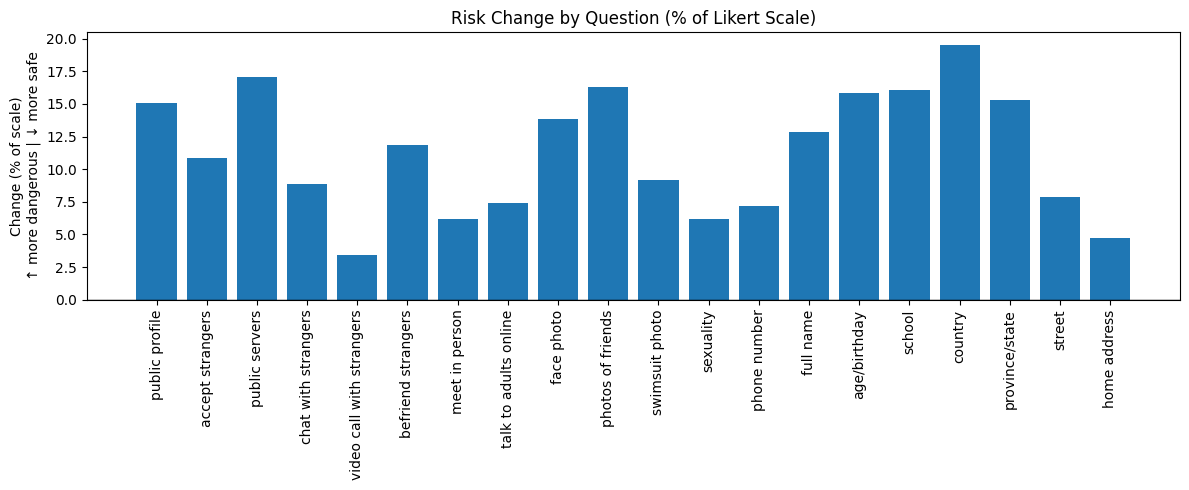

In [97]:
plt.figure(figsize=(12, 5))

# Normalizar a [-1, 1]
normalized_diff = (item_diff_df["diff"] / 5) * 100

plt.bar(item_diff_df["keyword"], normalized_diff)

plt.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=90)
plt.ylabel("Change (% of scale)\n↑ more dangerous | ↓ more safe")
plt.title("Risk Change by Question (% of Likert Scale)")

plt.tight_layout()
plt.show()


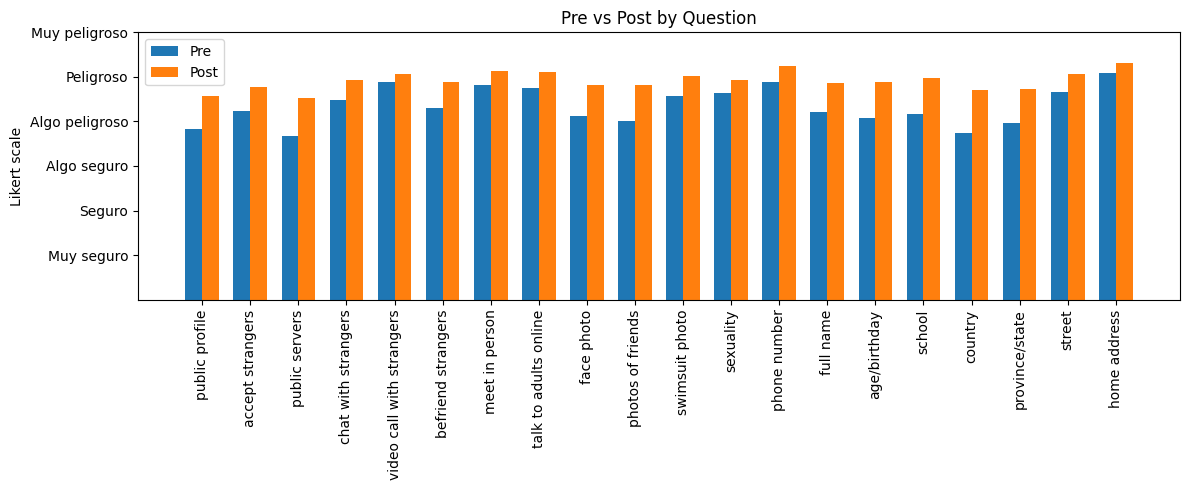

In [94]:
likert_labels = {
	1: "Muy seguro",
	2: "Seguro",
	3: "Algo seguro",
	4: "Algo peligroso",
	5: "Peligroso",
	6: "Muy peligroso"
}

x = np.arange(len(item_diff_df))
width = 0.35

plt.figure(figsize=(12, 5))

plt.bar(x - width/2, item_diff_df["pre"], width, label="Pre")
plt.bar(x + width/2, item_diff_df["post"], width, label="Post")

plt.xticks(x, item_diff_df["keyword"], rotation=90)
plt.yticks(list(likert_labels.keys()), list(likert_labels.values()))

plt.ylabel("Likert scale")
plt.title("Pre vs Post by Question")
plt.legend()

plt.tight_layout()
plt.show()
